In [15]:
from datasets import load_dataset
import matplotlib.pyplot as plt
import pandas as pd

In [16]:
ds = load_dataset("cambridgeltl/vsr_zeroshot")
df = ds["train"].to_pandas()

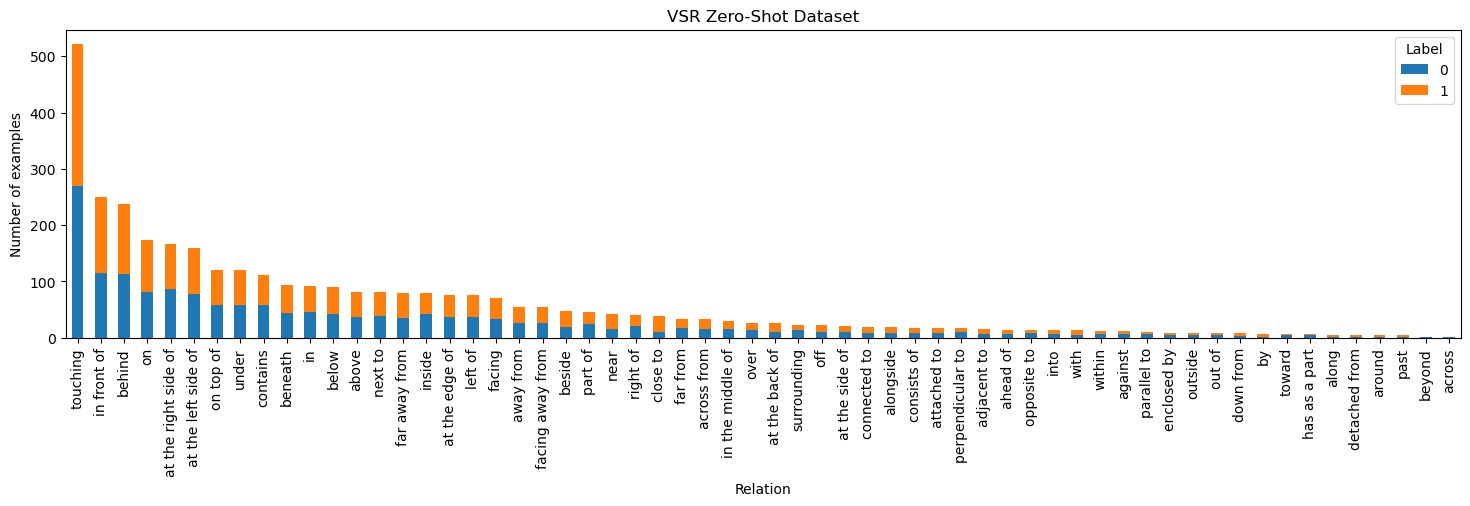

In [17]:
# Plot bars per relation where lower part of bar is quantity of label = 0 and upper part (in different color) is label = 1 -> df[['relation', 'label']]
plot_data = df[['relation', 'label']].groupby(['relation', 'label']).size().unstack()
plot_data['total'] = plot_data.sum(axis=1)
plot_data = plot_data.sort_values(by='total', ascending=False).drop(columns='total')

plot_data.plot(kind='bar', stacked=True, figsize=(18, 4))
plt.title("VSR Zero-Shot Dataset")
plt.xlabel("Relation")
plt.ylabel("Number of examples")
plt.xticks(rotation=90)
plt.legend(title="Label", loc='upper right', labels=['0', '1'])

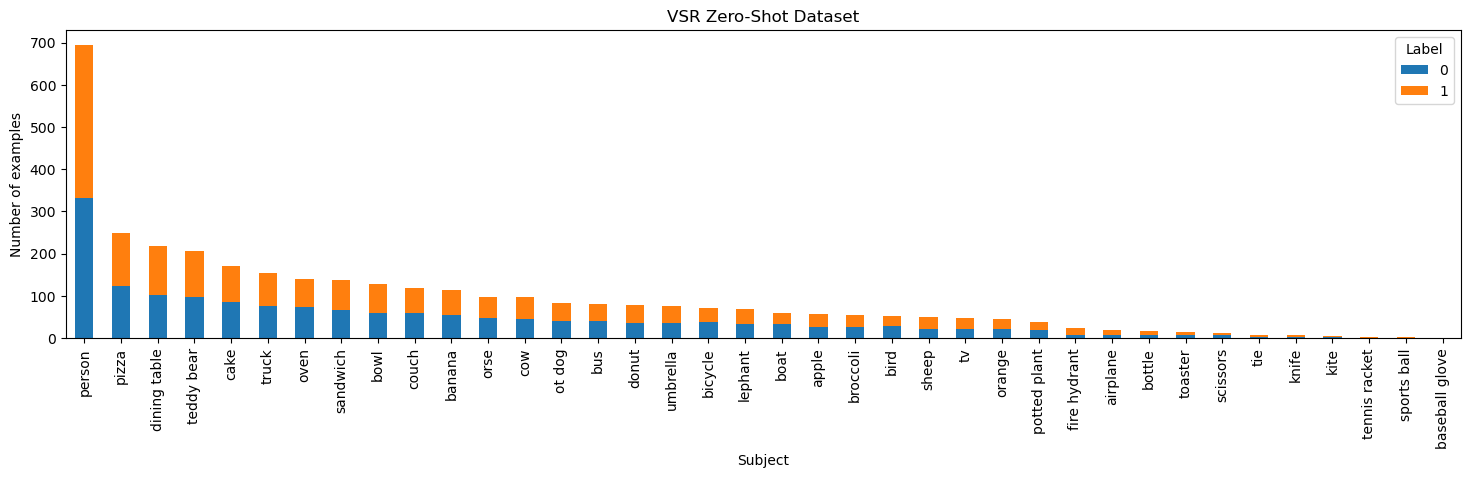

In [18]:
# Plot bars per relation where lower part of bar is quantity of label = 0 and upper part (in different color) is label = 1 -> df[['relation', 'label']]
plot_data = df[['subj', 'label']].groupby(['subj', 'label']).size().unstack()
plot_data['total'] = plot_data.sum(axis=1)
plot_data = plot_data.sort_values(by='total', ascending=False).drop(columns='total')

plot_data.plot(kind='bar', stacked=True, figsize=(18, 4))
plt.title("VSR Zero-Shot Dataset")
plt.xlabel("Subject")
plt.ylabel("Number of examples")
plt.xticks(rotation=90)
plt.legend(title="Label", loc='upper right', labels=['0', '1'])
plt.show()

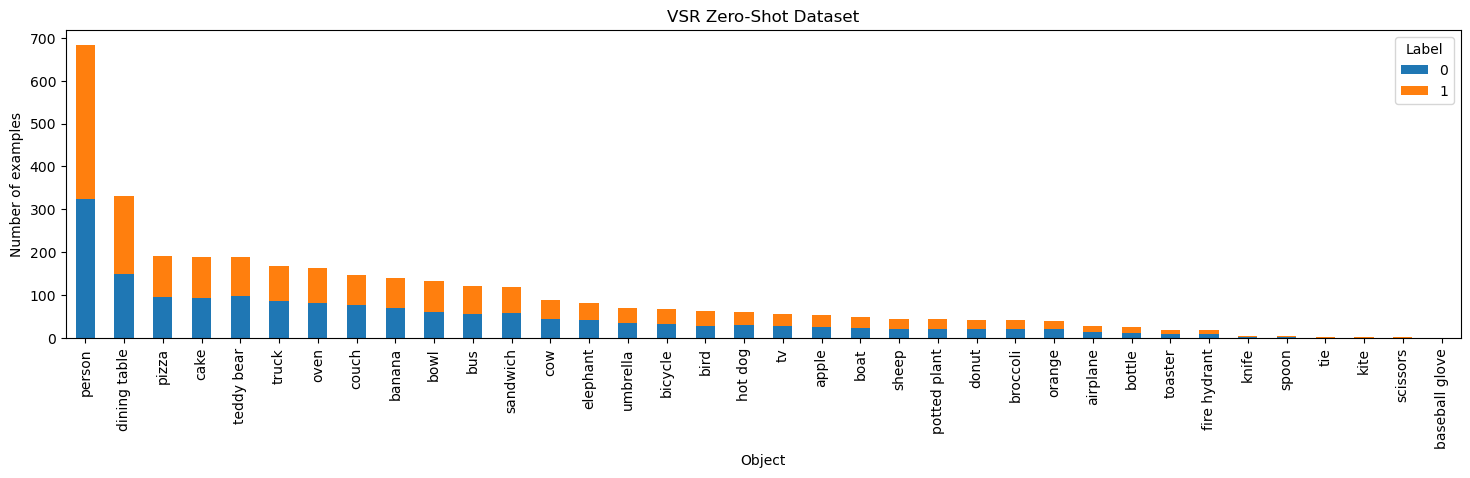

In [19]:
# Plot bars per relation where lower part of bar is quantity of label = 0 and upper part (in different color) is label = 1 -> df[['relation', 'label']]
plot_data = df[['obj', 'label']].groupby(['obj', 'label']).size().unstack()
plot_data['total'] = plot_data.sum(axis=1)
plot_data = plot_data.sort_values(by='total', ascending=False).drop(columns='total')

plot_data.plot(kind='bar', stacked=True, figsize=(18, 4))
plt.title("VSR Zero-Shot Dataset")
plt.xlabel("Object")
plt.ylabel("Number of examples")
plt.xticks(rotation=90)
plt.legend(title="Label", loc='upper right', labels=['0', '1'])
plt.show()

# Under-Sampling

In [20]:
def undersample_by_relation(df,
                            keep_ratio=0.8,
                            seed=42):
    """
    For the listed relations:
      • keep **all** rows where label == minority_label
      • keep only `keep_ratio` of rows where label != minority_label
    All other relations are left untouched.
    """
    
    # Empty DataFrame to store the new data
    df_biased = pd.DataFrame(columns=df.columns)

    for rel, group in df.groupby('relation'):
        # Split into minority / majority within this relation
        group_count = group['label'].value_counts()
        
        minority_label = group_count.idxmin()
        majority_label = group_count.idxmax()
        
        group_min = group[group['label'] == minority_label]
        group_maj = group[group['label'] == majority_label]
        
        # Remove random from minority
        n_keep = int(len(group_min) * keep_ratio)
        n_drop = len(group_min) - n_keep
        if n_drop > 0:
            group_min_to_keep = group_min.sample(n=n_keep, random_state=seed)
        else:
            group_min_to_keep = group_min.sample(n=0, random_state=seed)
            
        new_group = pd.concat([group_maj, group_min_to_keep])
        df_biased = pd.concat([df_biased, new_group])  
        
    df_biased['label'] = df_biased['label'].astype('int')    
    
    return df_biased.reset_index(drop=True)

# Example: make 'touching', 'in front of', 'on' mostly positive
df_relation_biased = undersample_by_relation(df,
                                             keep_ratio=0.8)



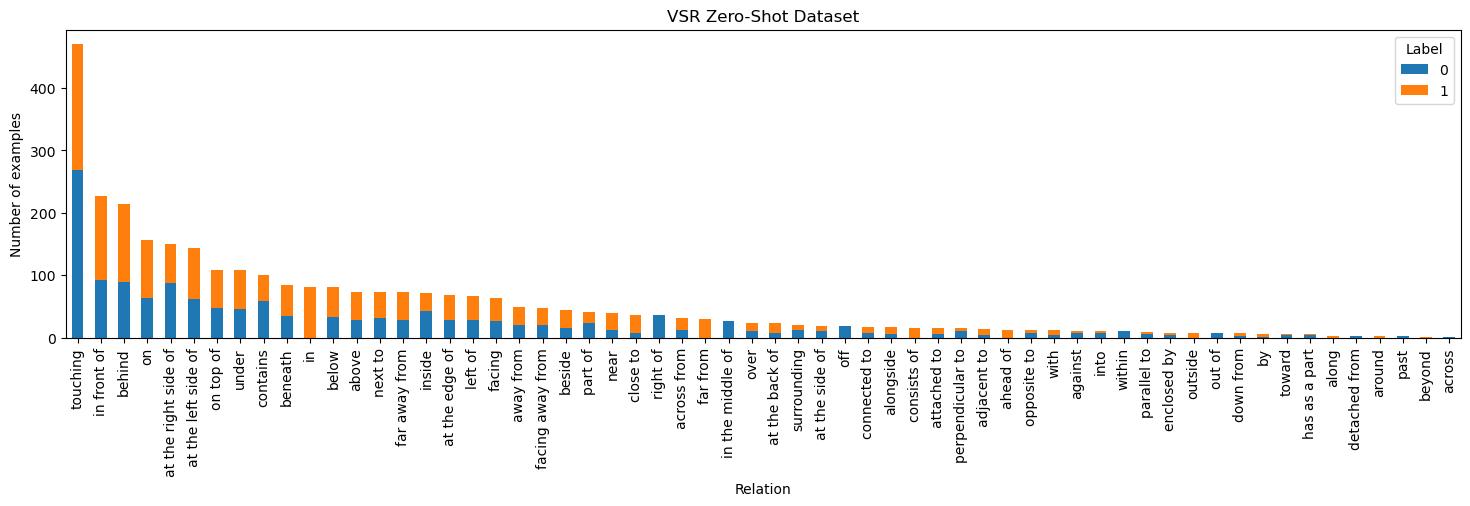

In [21]:
# Plot bars per relation where lower part of bar is quantity of label = 0 and upper part (in different color) is label = 1 -> df[['relation', 'label']]
plot_data = df_relation_biased[['relation', 'label']].groupby(['relation', 'label']).size().unstack()
plot_data['total'] = plot_data.sum(axis=1)
plot_data = plot_data.sort_values(by='total', ascending=False).drop(columns='total')

plot_data.plot(kind='bar', stacked=True, figsize=(18, 4))
plt.title("VSR Zero-Shot Dataset")
plt.xlabel("Relation")
plt.ylabel("Number of examples")
plt.xticks(rotation=90)
plt.legend(title="Label", loc='upper right', labels=['0', '1'])
plt.show()

In [22]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

model = smf.ols('label ~ relation', data=df_relation_biased).fit()
# Print the summary of the model
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  label   R-squared:                       0.113
Model:                            OLS   Adj. R-squared:                  0.096
Method:                 Least Squares   F-statistic:                     6.664
Date:                Tue, 22 Apr 2025   Prob (F-statistic):           3.22e-47
Time:                        00:55:49   Log-Likelihood:                -2077.3
No. Observations:                3137   AIC:                             4275.
Df Residuals:                    3077   BIC:                             4638.
Df Model:                          59                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

# Add Vision Bias

In [23]:
from datasets import load_from_disk
import os
from dotenv import load_dotenv
load_dotenv()

disk_loc = os.path.join(os.environ["DATA_PATH"], "vsr")

In [24]:
from datasets import Dataset
from torch.utils.data import DataLoader
from torchvision import transforms
from PIL import Image
from tqdm.auto import tqdm
import torch
import random

random.seed(42)
torch.manual_seed(42)

image_size = 32
batch_size = 64
num_workers = 8

bias_prob = 0.3
bias_strength = 0.15

dataset = load_from_disk(disk_loc)

transform = transforms.Compose([
    transforms.Resize((image_size, image_size), antialias=True),
    transforms.ToTensor(),          # → float tensor in [0,1]
])

def add_pixel_values(example):
    img = Image.open(example["image_path"]).convert("RGB")
    px = transform(img)  # shape: (3, H, W), values in [0,1]

    # Subtle color bias: boost red for label 1, blue for label 0
    if random.random() < bias_prob:
        # add on random subset
        H, W = px.shape[1:]
        mask = torch.zeros((H, W), dtype=torch.bool)
        mask[torch.randint(0, H, (H // 2,)), torch.randint(0, W, (W // 2,))] = True
        
        if example["label"] == 1:
            mask[torch.randint(0, H, (H // 2,)), torch.randint(0, W, (W // 2,))] = True
            px[1][mask] = torch.clamp(px[1][mask] + bias_strength, 0, 1)  # Subtract 5% green
        else:
            px[2][mask] = torch.clamp(px[2][mask] + bias_strength, 0, 1)  # Subtract 5% green

    example["pixel_values"] = px
    return example

for split in dataset.keys():
    dataset[split] = dataset[split].map(
        add_pixel_values,
        remove_columns=["image_path"],              # drop once it’s inside pixel_values
        num_proc=num_workers,                       # parallel workers (optional)
    )

# ------------------------------------------------------------------
# 6. Tell datasets to yield PyTorch tensors
# ------------------------------------------------------------------
dataset.set_format(type="torch",
                   columns=["pixel_values", "label"], output_all_columns=False)  # include any columns you need


loader_train = DataLoader(dataset['train'], batch_size=batch_size, num_workers=num_workers, shuffle=True, drop_last=True)
loader_val = DataLoader(dataset['validation'], batch_size=batch_size, num_workers=num_workers, drop_last=False)
loader_test = DataLoader(dataset['test'], batch_size=batch_size, num_workers=num_workers, drop_last=False)



Map (num_proc=8):   0%|          | 0/3489 [00:00<?, ? examples/s]

Map (num_proc=8):   0%|          | 0/340 [00:00<?, ? examples/s]

Map (num_proc=8):   0%|          | 0/1222 [00:00<?, ? examples/s]

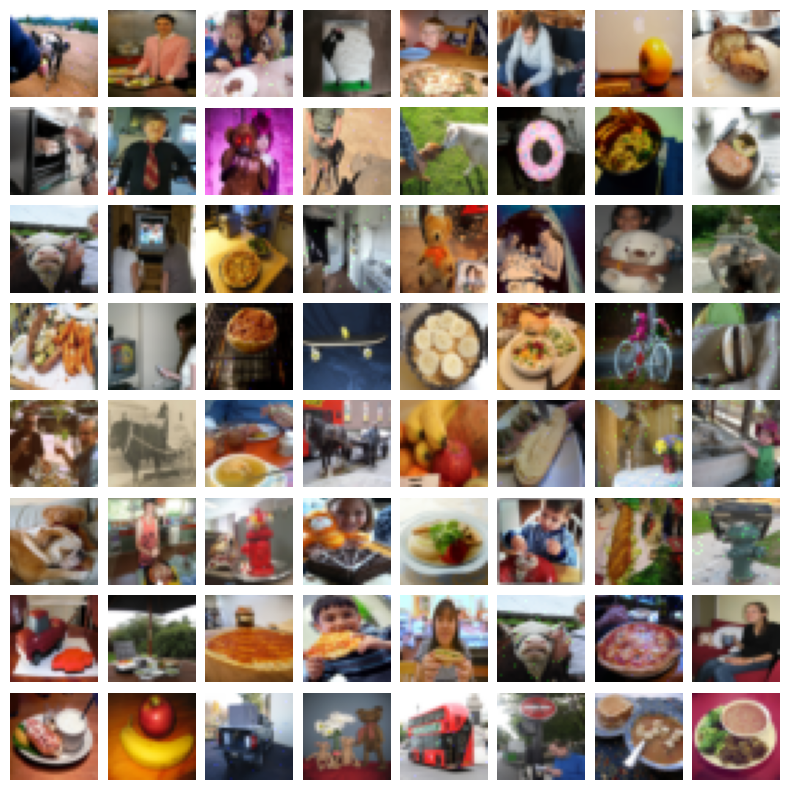

In [25]:
from mpl_toolkits.axes_grid1 import ImageGrid

batch      = next(iter(loader_train))
imgs       = batch["pixel_values"]      # (B, C, 14, 14)
cls_idxs   = batch["label"]             # (B,)

fig = plt.figure(figsize=(10, 10))
grid = ImageGrid(fig, 111, nrows_ncols=(8, 8), axes_pad=0.1)

for ax, img in zip(grid, imgs):         # imgs is a tensor now
    ax.imshow(img.squeeze().permute(1,2,0).numpy(), cmap='gray')  # or .permute(1,2,0) for RGB
    ax.axis("off")

plt.show()


In [26]:
from find_visual_biases_script import ViT
import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

vit = ViT(
    img_size=image_size, patch_size=2, in_channels=3, 
    embed_dim=64, num_classes=2, depth=2, 
    num_heads=4, mlp_ratio=4., 
).to(device)
optimizer = torch.optim.AdamW(vit.parameters())
num_parameters = sum([p.numel() for p in vit.parameters()])
print(f'Number of parameters: {num_parameters:,}')

Using device: cuda
Number of parameters: 116,928


In [27]:
num_epochs = 20

train_losses = []
val_losses = []
val_accuracies = []

for _ in range(num_epochs):
        
    # Train loop
    vit.train()
    epoch_loss_train = 0
    pbar = tqdm(total=len(loader_train))
    for batch in loader_train:        
        
        inputs, targets = batch['pixel_values'].to(device), batch['label'].to(device)

        logits = vit(inputs)
        loss = F.cross_entropy(logits, targets)

        vit.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        
        epoch_loss_train += loss.item()
        
        pbar.update(1)
        pbar.set_description(f'Train loss: {loss.item():.3f}')
    pbar.close()
    
    epoch_loss_train /= len(loader_train)
    train_losses.append(epoch_loss_train)
    
    
    # Validation loop
    vit.eval()
    epoch_loss_val = 0
    correct = 0
    for batch in loader_val:
        inputs, targets = batch['pixel_values'].to(device), batch['label'].to(device)

        with torch.no_grad():
            logits = vit(inputs)
        loss = F.cross_entropy(logits, targets)
        
        pred = logits.argmax(dim=1, keepdim=True)
        correct += pred.eq(targets.view_as(pred)).sum().item()
        
        epoch_loss_val += loss.item()
        
    accuracy = correct / len(loader_val.dataset)
    
    epoch_loss_val /= len(loader_val)
    val_losses.append(epoch_loss_val)
    val_accuracies.append(accuracy)
    
    print(f'Train loss: {epoch_loss_train:.3f}, val loss: {epoch_loss_val:.3f}, val accuracy: {accuracy:.3f}')
    
torch.save(vit.state_dict(), f"vit_biased_30pct_strength_15.pth")

  0%|          | 0/54 [00:00<?, ?it/s]

Train loss: 0.700, val loss: 0.697, val accuracy: 0.488


  0%|          | 0/54 [00:00<?, ?it/s]

Train loss: 0.697, val loss: 0.708, val accuracy: 0.491


  0%|          | 0/54 [00:00<?, ?it/s]

...

Train loss: 0.687, val loss: 0.703, val accuracy: 0.491


  0%|          | 0/54 [00:00<?, ?it/s]

Train loss: 0.684, val loss: 0.704, val accuracy: 0.479


  0%|          | 0/54 [00:00<?, ?it/s]

Train loss: 0.686, val loss: 0.709, val accuracy: 0.471


In [28]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=1, image_size=32):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.fc1 = nn.Linear(32 * (image_size // 4) * (image_size // 4), 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, kernel_size=2, stride=2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, kernel_size=2, stride=2)
        x = x.view(x.size(0), -1)  # Flatten
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x
    
cnn = SimpleCNN(num_classes=1, image_size=image_size).to(device)
optimizer = torch.optim.AdamW(cnn.parameters())
num_parameters = sum([p.numel() for p in cnn.parameters()])
print(f'Number of parameters: {num_parameters:,}')

num_epochs = 20
train_losses = []
val_losses = []
val_accuracies = []

for _ in range(num_epochs):
    # Train loop
    cnn.train()
    epoch_loss_train = 0
    pbar = tqdm(total=len(loader_train))
    for batch in loader_train:        
        
        inputs, targets = batch['pixel_values'].to(device), batch['label'].to(device)

        logits = cnn(inputs)
        
        # BCE loss
        loss = nn.BCEWithLogitsLoss()(logits, targets.float().unsqueeze(1))
        # loss = F.binary_cross_entropy_with_logits(logits, targets.float().unsqueeze(1))

        cnn.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        
        epoch_loss_train += loss.item()
        
        pbar.update(1)
        pbar.set_description(f'Train loss: {loss.item():.3f}')
    pbar.close()
    
    epoch_loss_train /= len(loader_train)
    train_losses.append(epoch_loss_train)
    
    
    # Validation loop
    cnn.eval()
    epoch_loss_val = 0
    correct = 0
    for batch in loader_val:
        inputs, targets = batch['pixel_values'].to(device), batch['label'].to(device)

        with torch.no_grad():
            logits = cnn(inputs)
        
        loss = nn.BCEWithLogitsLoss()(logits, targets.float().unsqueeze(1))
    
        pred = (logits.squeeze() > 0).float()
        correct += pred.eq(targets.view_as(pred)).sum().item()
        
        epoch_loss_val += loss.item()
        
    accuracy = correct / len(loader_val.dataset)
    
    epoch_loss_val /= len(loader_val)
    val_losses.append(epoch_loss_val)
    val_accuracies.append(accuracy)
    
    print(f'Train loss: {epoch_loss_train:.3f}, val loss: {epoch_loss_val:.3f}, val accuracy: {accuracy:.3f}')
torch.save(cnn.state_dict(), f"cnn_biased_30pct_strength_15.pth")

Number of parameters: 267,489


  0%|          | 0/54 [00:00<?, ?it/s]

Train loss: 0.693, val loss: 0.696, val accuracy: 0.491


  0%|          | 0/54 [00:00<?, ?it/s]

Train loss: 0.693, val loss: 0.698, val accuracy: 0.491


...

Train loss: 0.616, val loss: 0.720, val accuracy: 0.518


  0%|          | 0/54 [00:00<?, ?it/s]

Train loss: 0.605, val loss: 0.746, val accuracy: 0.553


  0%|          | 0/54 [00:00<?, ?it/s]

Train loss: 0.601, val loss: 0.733, val accuracy: 0.529
